# Лабораторная работа 12. Отравление данных и атаки на приватность


**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 9**

Курс «Глубокое обучение и безопасность нейронных сетей». Уровень: бакалавриат, Python и основы PyTorch.

**Вариант / seed:** вариант 1, `SEED = 42`

Все эксперименты выполняются на собственных локальных моделях, открытых цифрах 8×8 и синтетических векторах.
Нет внешних API, персональных данных, ключей или скачивания весов.

## План

| Блок | Эксперимент | Главный вопрос |
|---|---|---|
| A | Baseline и label flipping | Что меняется при повреждении меток? |
| B | Backdoor и контроль известного триггера | Может ли высокая clean accuracy скрывать уязвимость? |
| C | Membership inference, shadow calibration | Насколько loss выдаёт участие в обучении? |
| D | Model inversion | Восстановлен образ класса или конкретная запись? |
| E | Model extraction | Чем fidelity отличается от accuracy? |
| F | Выводы и воспроизводимость | Какие утверждения действительно подтверждены? |


Выполняйте «Restart Kernel → Run All». CPU достаточен; время зависит от компьютера.
Не оценивайте качество работы по тому, удалось ли получить «красивую» атаку.
Корректный отрицательный результат с проверенной реализацией является полноценным результатом.

Реализуйте 6 кодовых заданий (8 функций) и аналитическое задание F1. Заглушки возвращают None: зависимые опыты честно пропускаются, а не подменяются готовыми ответами.

In [ ]:
# При необходимости выполните ОДИН РАЗ, затем перезапустите ядро:
# %pip install torch numpy scipy scikit-learn pandas matplotlib nbformat
import sys, time, copy, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
import sklearn
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, balanced_accuracy_score
from IPython.display import display

START = time.perf_counter()
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
print({"Python": platform.python_version(), "torch": torch.__version__,
       "numpy": np.__version__, "sklearn": sklearn.__version__, "device": DEVICE})

def tensor(x):
    return torch.as_tensor(x, dtype=torch.float32)

def new_model(d, k, seed=SEED, width=64):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(d, width), nn.ReLU(),
                         nn.Linear(width, width), nn.ReLU(), nn.Linear(width, k))

def fit(x, y, k=10, epochs=140, wd=1e-4, seed=SEED, width=64, soft=False):
    model = new_model(x.shape[1], k, seed, width)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=wd)
    xt = tensor(x)
    yt = tensor(y) if soft else torch.as_tensor(y, dtype=torch.long)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(xt)
        loss = -(yt * F.log_softmax(logits, dim=1)).sum(1).mean() if soft else F.cross_entropy(logits, yt)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return model.eval(), history

def probs(model, x):
    with torch.no_grad():
        return model(tensor(x)).softmax(1).numpy()

def acc(model, x, y):
    return accuracy_score(y, probs(model, x).argmax(1))

def pending(name):
    print(f"{name}: не выполнено. Реализуйте TODO и повторите Run All.")

results = {}

{'Python': '3.12.3', 'torch': '2.4.1+cu121', 'numpy': '2.4.4', 'sklearn': '1.8.0', 'device': 'cpu'}


## A. Данные и честный контроль

Digits из scikit-learn загружается локально и не требует сети. Делим исходные индексы ДО атак:
600 train, 197 validation, 500 public query pool, 500 test.
Чистый test не участвует в обучении и извлечении; pool не участвует в обучении teacher.
Параметры опытов заранее зафиксированы: не подбирайте их по итоговому test.
Данные public pool видит атакующий extraction, но его исходные метки в обучении клона не используются.

,train_accuracy,validation_accuracy,test_accuracy
0,1.0,0.954315,0.96


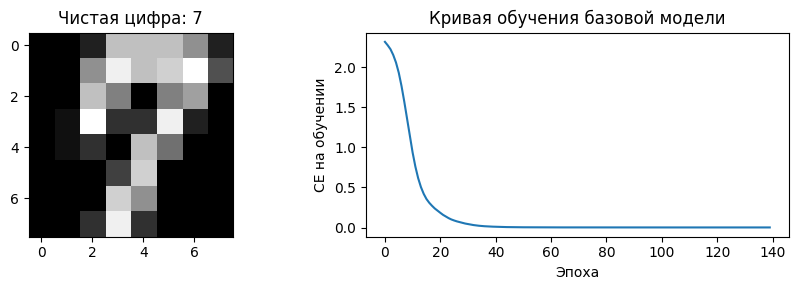

In [ ]:
digits = load_digits()
X = (digits.data / 16.0).astype(np.float32)
y = digits.target
ids = np.arange(len(y))
rest, test_ids = train_test_split(ids, test_size=500, random_state=42, stratify=y)
rest, pool_ids = train_test_split(rest, test_size=500, random_state=43, stratify=y[rest])
train_ids, val_ids = train_test_split(rest, train_size=600, random_state=44, stratify=y[rest])
groups = [train_ids, val_ids, pool_ids, test_ids]
assert len(set(np.concatenate(groups))) == len(X)
for i in range(4):
    for j in range(i):
        assert not set(groups[i]) & set(groups[j])
Xtr, ytr = X[train_ids], y[train_ids]
Xval, yval = X[val_ids], y[val_ids]
Xpool = X[pool_ids]
Xte, yte = X[test_ids], y[test_ids]
clean, clean_hist = fit(Xtr, ytr)
baseline_acc = acc(clean, Xte, yte)
results["baseline"] = {"train_accuracy": acc(clean, Xtr, ytr),
                       "validation_accuracy": acc(clean, Xval, yval),
                       "test_accuracy": baseline_acc}
display(pd.DataFrame([results["baseline"]]))
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].imshow(Xtr[0].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
ax[0].set_title(f"Чистая цифра: {ytr[0]}")
ax[1].plot(clean_hist); ax[1].set(xlabel="Эпоха", ylabel="CE на обучении", title="Кривая обучения базовой модели")
plt.tight_layout(); plt.show()

**Вывод.** Базовая модель доучивается до train accuracy 1.0 и даёт 0.960 на тесте; loss гладко падает, обучение сошлось. Это точка отсчёта для всех атак ниже.

### Задание A1. Label flipping

Реализуйте изменение ровно `floor(rate * n)` меток без изменения входов и без изменения исходного массива.
Новая метка должна отличаться от старой. Сравните доли 0, 0.1, 0.3 при одинаковой инициализации модели.
Это простой baseline отравления, а не оптимизированная атака.

In [ ]:
def flip_labels(y, rate, k, seed=42):
    """Меняет ровно floor(rate*n) меток на ДРУГИЕ, не трогая входы и исходный массив.

    Возвращает (новый массив меток, индексы изменённых). Новая метка != старой:
    берём ненулевой сдвиг по модулю k, поэтому гарантированно отличается.
    """
    y = np.asarray(y)
    n = len(y)
    n_flip = int(np.floor(rate * n))
    yf = y.copy()                                   # копия: исходный массив не меняется
    rng = np.random.default_rng(seed)
    changed = rng.choice(n, size=n_flip, replace=False)   # выбор без возвращения
    shift = rng.integers(1, k, size=n_flip)         # сдвиг 1..k-1 — ненулевой
    yf[changed] = (y[changed] + shift) % k          # новая метка заведомо отличается
    return yf, changed

,poison_rate,n_changed,clean_test_accuracy
0,0.0,0,0.960
1,0.1,60,0.852
2,0.3,180,0.652


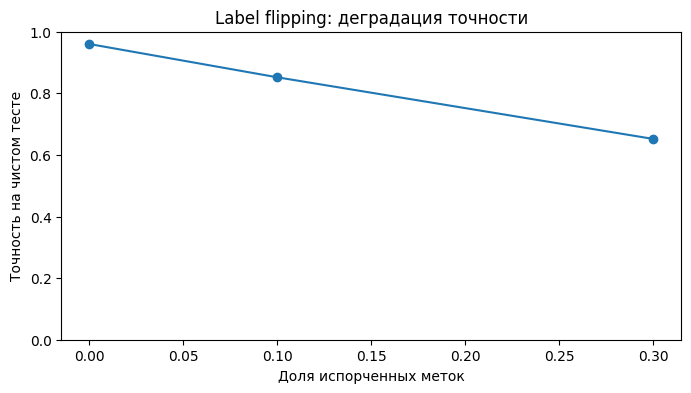

In [ ]:
flip_probe = flip_labels(ytr, 0.1, 10)
if flip_probe is None:
    pending("A1")
else:
    yf, changed = flip_probe
    assert len(changed) == 60 and np.sum(yf != ytr) == 60
    assert np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(yf, ytr)
    flip_rows = []
    for rate in [0, 0.1, 0.3]:
        yf, changed = flip_labels(ytr, rate, 10)
        m = clean if rate == 0 else fit(Xtr, yf)[0]
        flip_rows.append({"poison_rate": rate, "n_changed": len(changed),
                         "clean_test_accuracy": acc(m, Xte, yte)})
    results["label_flipping"] = flip_rows
    display(pd.DataFrame(flip_rows))
    plt.plot([r["poison_rate"] for r in flip_rows],
             [r["clean_test_accuracy"] for r in flip_rows], "o-")
    plt.xlabel("Доля испорченных меток"); plt.ylabel("Точность на чистом тесте"); plt.title("Label flipping: деградация точности")
    plt.ylim(0, 1); plt.show()

**Вывод.** Точность падает почти линейно: 0.960 → 0.852 при 10 % испорченных меток и до 0.652 при 30 %. Модель запоминает неверные метки, поэтому каждая испорченная доля прямо стоит точности.

## B. Backdoor: локальный dirty-label опыт

Атакующий заменяет часть train на изображения с патчем 2×2 в правом нижнем углу и меткой `target=0`.
При инференсе тот же патч должен направлять нетаргетные цифры в класс 0.
Это учебная реализация идеи [BadNets](https://arxiv.org/abs/1708.06733), не точное воспроизведение статьи.
Доля отравления определяется от ВСЕХ 600 train, а выбираются только записи с исходной меткой, отличной от 0.

$
ASR=\frac{\sum_{i:y_i\ne t}1[\arg\max f(T(x_i))=t]}{|\{i:y_i\ne t\}|}.
$

Проверяем четыре условия: clean model / poisoned model × clean input / triggered input.
ASR clean-модели на том же триггере показывает, не объясняется ли эффект одним повреждением входа.
Дополнительно считаем условный ASR на тех нетаргетных объектах, которые эта же модель правильно распознавала без патча.

### Задание B1. Триггер и отравление

`trigger` должен копировать вход, сохранять форму `(n,64)` и менять только последние 2×2 пикселя.
`poison_data` заменяет, а не добавляет записи; возвращает индексы изменений.
Для воспроизводимого сравнения выбор индексов должен зависеть только от `seed`.

In [ ]:
TARGET = 0
def trigger(x):
    """Ставит белый патч 2x2 в правый нижний угол. Копия, форма (n,64) сохраняется."""
    z = np.array(x, dtype=np.float32, copy=True).reshape(-1, 8, 8)
    z[:, -2:, -2:] = 1.0
    return z.reshape(-1, 64)

def poison_data(x, y, rate=0.15, target=TARGET, seed=42):
    """Заменяет floor(rate*n) записей с меткой != target на (патч, target).

    Доля считается от ВСЕХ n записей; индексы зависят только от seed.
    Возвращает (новые x, новые y, индексы изменённых).
    """
    x = np.asarray(x); y = np.asarray(y)
    n = len(y)
    n_poison = int(np.floor(rate * n))
    rng = np.random.default_rng(seed)
    candidates = np.flatnonzero(y != target)        # отравляем только нетаргетные
    idx = rng.choice(candidates, size=n_poison, replace=False)
    xp = x.copy(); yp = y.copy()
    xp[idx] = trigger(x[idx])                        # и изображение,
    yp[idx] = target                                 # и метка
    return xp, yp, idx

def targeted_asr(pred, y, target):
    """Доля нетаргетных объектов, уведённых в target. NaN, если таких объектов нет."""
    pred = np.asarray(pred); y = np.asarray(y)
    mask = y != target                               # знаменатель — только y != target
    if mask.sum() == 0:
        return float("nan")
    return float((pred[mask] == target).mean())

### Задание B2. Корректный знаменатель

Реализуйте ASR по уже вычисленным предсказаниям; возвращайте NaN, если допустимых объектов нет.
Не включайте истинный target-класс. Вызов не должен изменять массивы.

,model,clean_accuracy,ASR,ASR_n,conditional_ASR,conditional_n,triggered_accuracy
0,clean,0.960,0.0,450,0.0,432,0.742
1,poisoned,0.956,1.0,450,1.0,429,0.100


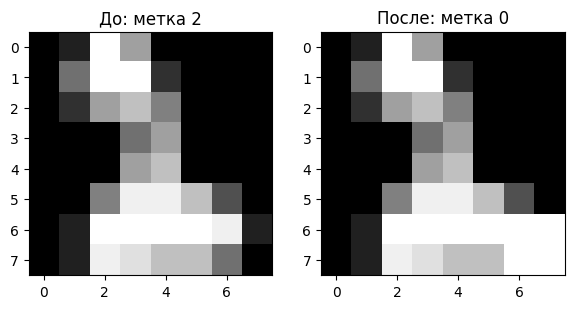

In [ ]:
poisoned = None
probe = poison_data(Xtr, ytr)
asr_probe = targeted_asr(np.array([0, 0, 1]), np.array([0, 2, 3]), 0)
if probe is None or asr_probe is None or trigger(Xtr[:1]) is None:
    pending("B1/B2")
else:
    assert asr_probe == 0.5
    assert np.isnan(targeted_asr(np.array([0]), np.array([0]), 0))
    xp, yp, ix = probe
    assert len(ix) == 90 and np.all(yp[ix] == TARGET) and np.all(ytr[ix] != TARGET)
    keep = np.setdiff1d(np.arange(len(ytr)), ix)
    assert np.array_equal(xp[keep], Xtr[keep])
    assert np.array_equal(Xtr, X[train_ids]) and np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(xp, Xtr)
    assert np.all(trigger(Xtr[:2]).reshape(-1, 8, 8)[:, -2:, -2:] == 1)
    mask_pixels = np.ones((8, 8), bool); mask_pixels[-2:, -2:] = False
    assert np.array_equal(trigger(Xtr[:2]).reshape(-1,8,8)[:,mask_pixels],
                          Xtr[:2].reshape(-1,8,8)[:,mask_pixels])
    poisoned, _ = fit(xp, yp)
    bd_rows = []
    for name, model in [("clean", clean), ("poisoned", poisoned)]:
        pc = probs(model, Xte).argmax(1)
        pt = probs(model, trigger(Xte)).argmax(1)
        eligible = (yte != TARGET) & (pc == yte)
        bd_rows.append({"model": name, "clean_accuracy": accuracy_score(yte, pc),
                        "ASR": targeted_asr(pt, yte, TARGET),
                        "ASR_n": int((yte != TARGET).sum()),
                        "conditional_ASR": float((pt[eligible] == TARGET).mean()),
                        "conditional_n": int(eligible.sum()),
                        "triggered_accuracy": accuracy_score(yte, pt)})
    results["backdoor"] = bd_rows
    display(pd.DataFrame(bd_rows))
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(Xtr[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"До: метка {ytr[ix[0]]}")
    ax[1].imshow(xp[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title(f"После: метка {yp[ix[0]]}")
    plt.tight_layout(); plt.show()

**Вывод.** Отравленная модель на чистых данных почти неотличима от чистой (0.956 против 0.960), но на триггере ASR = 1.0, а точность падает до 0.100. Чистая модель на том же патче даёт ASR 0 (хотя её точность снижается до 0.742) — значит направленный эффект создан обучением, а не самим патчем.

### Контроль защиты с известным триггером

Ниже защитник УЖЕ знает положение патча. Он зануляет эту область на ВСЕХ входах.
Это oracle-sanitization: полезный контроль причинности, но не детектор неизвестных backdoor.
Считаем и ASR, и потерю clean accuracy. Дополнительный опыт: fine-tuning на чистой validation;
после него эта выборка становится обучающей и больше не годится для независимой оценки.
Ни один из этих опытов не даёт универсальной гарантии ([NIST](https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.100-2e2025.pdf)).

,defense,clean_accuracy,ASR
0,No defense,0.956,1.000000
1,Known patch erase,0.956,0.002222
2,Clean fine-tuning,0.960,0.997778


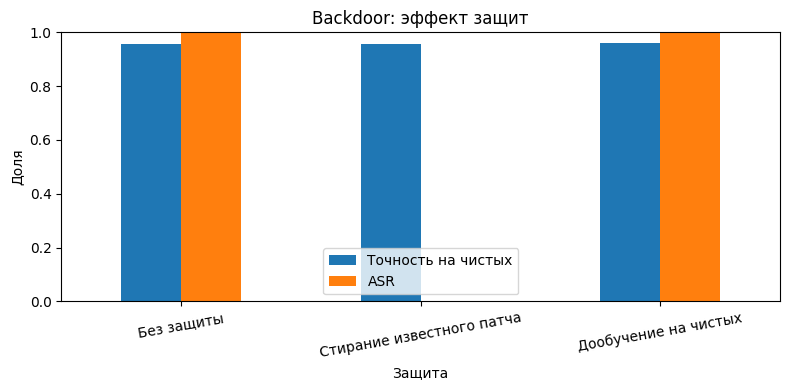

In [ ]:
def erase_known_patch(x):
    z = x.copy().reshape(-1,8,8)
    z[:, -2:, -2:] = 0
    return z.reshape(-1,64)

if poisoned is not None:
    ft = copy.deepcopy(poisoned)
    opt = torch.optim.Adam(ft.parameters(), lr=0.001)
    for _ in range(40):
        opt.zero_grad()
        loss = F.cross_entropy(ft(tensor(Xval)), torch.as_tensor(yval, dtype=torch.long))
        loss.backward(); opt.step()
    defense_rows = []
    for name, model, transform in [
        ("No defense", poisoned, lambda x: x),
        ("Known patch erase", poisoned, erase_known_patch),
        ("Clean fine-tuning", ft.eval(), lambda x: x)]:
        defense_rows.append({"defense": name, "clean_accuracy": acc(model, transform(Xte), yte),
                            "ASR": targeted_asr(probs(model, transform(trigger(Xte))).argmax(1), yte, TARGET)})
    results["backdoor_defense"] = defense_rows
    display(pd.DataFrame(defense_rows))
    pd.DataFrame(defense_rows).replace({"No defense": "Без защиты", "Known patch erase": "Стирание известного патча", "Clean fine-tuning": "Дообучение на чистых"}).rename(columns={"clean_accuracy": "Точность на чистых", "ASR": "ASR"}).set_index("defense").plot.bar(rot=10, ylim=(0,1))
    plt.xlabel("Защита"); plt.ylabel("Доля"); plt.title("Backdoor: эффект защит")
    plt.tight_layout(); plt.show()
else:
    pending("Backdoor defense")

**Вывод.** Стирание известного патча снижает ASR с 1.0 до 0.002 без потери точности, но защитник заранее знал, где триггер. Дообучение на 197 чистых примерах почти не помогает (ASR 0.998): закладка переживает fine-tuning.

## C. Membership inference: отдельный синтетический стенд

Определяем, входила ли запись `(x,y)` в train целевой модели.
Loss-score требует истинной метки и вектора вероятностей: это явно заданные возможности атакующего.
Используем отрицательную cross-entropy, то есть `log p(y|x)`; больший score означает «вероятнее member».
Идея shadow calibration связана с [Shokri et al.](https://arxiv.org/abs/1610.05820).

1600 синтетических записей делятся на 4 непересекающихся набора по 400:
target members, target nonmembers, shadow members, shadow nonmembers.
Shadow-данные и алгоритм обучения доступны атакующему. Порог выбирается ТОЛЬКО на shadow;
истинные membership-метки target открываются лишь оценщику после атаки.
Один shadow не является реализацией LiRA. Цель: честно показать принцип калибровки.

### Задание C1. Loss-score и порог

Напишите `membership_score` через логарифм вероятности истинного класса с защитой от log(0).
В `choose_threshold` максимизируйте balanced accuracy на calibration, перебрав уникальные score
и дополнительный порог выше максимума. Используйте соглашение `score >= threshold`.

In [ ]:
def membership_score(p, labels):
    """log p(истинного класса) с защитой от log(0). Больше score => вероятнее member."""
    p = np.asarray(p); labels = np.asarray(labels)
    true_p = p[np.arange(len(labels)), labels]
    return np.log(np.clip(true_p, 1e-12, 1.0))

def choose_threshold(scores, member):
    """Порог, максимизирующий balanced accuracy на calibration (соглашение score >= threshold).

    Перебираем все уникальные score как пороги плюс один порог выше максимума
    (чтобы допускать решение «никто не member»).
    """
    scores = np.asarray(scores); member = np.asarray(member)
    candidates = np.r_[np.unique(scores), scores.max() + 1.0]
    best_t, best_ba = candidates[0], -1.0
    for t in candidates:
        ba = balanced_accuracy_score(member, scores >= t)
        if ba > best_ba:
            best_ba, best_t = ba, t
    return float(best_t)

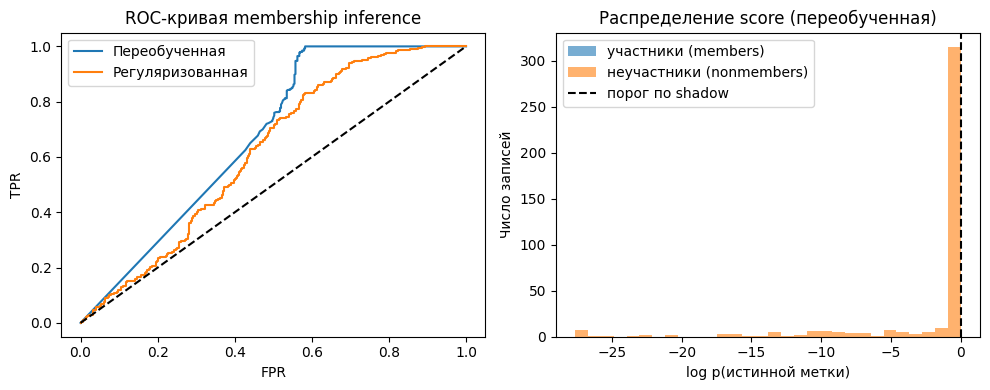

,setting,train_accuracy,nonmember_accuracy,gap,threshold_shadow,ROC_AUC,balanced_accuracy,TPR,FPR,advantage,TPR_at_empirical_FPR_le_1pct
0,Overfit,1.0000,0.7825,0.2175,-0.000037,0.671647,0.70750,1.00,0.5850,0.4150,0.00
1,Regularized,0.9825,0.8175,0.1650,-0.337438,0.618344,0.62125,0.94,0.6975,0.2425,0.01


Минимальный ненулевой шаг FPR = 0.0025 ; 1% соответствует всего 4 FP, оценка нестабильна.


In [ ]:
mia_probe = membership_score(np.array([[.9,.1],[.2,.8]]), np.array([0,1]))
if mia_probe is None or choose_threshold(np.array([-2., -1.]), np.array([0,1])) is None:
    pending("C1")
else:
    np.testing.assert_allclose(mia_probe, np.log([.9,.8]))
    threshold_probe = choose_threshold(np.array([-3.,-2.,-1.,-.1]), np.array([0,0,1,1]))
    assert balanced_accuracy_score([0,0,1,1], np.array([-3.,-2.,-1.,-.1]) >= threshold_probe) == 1
    XM, yM = make_classification(n_samples=1600, n_features=40, n_informative=12,
                                 n_redundant=8, class_sep=0.7, flip_y=0.08, random_state=51)
    mi = np.arange(1600)
    a, b = train_test_split(mi, test_size=800, random_state=52, stratify=yM)
    tm, tn = train_test_split(a, test_size=400, random_state=53, stratify=yM[a])
    sm, sn = train_test_split(b, test_size=400, random_state=54, stratify=yM[b])
    assert len(set(np.r_[tm,tn,sm,sn])) == 1600
    # Фиксированное масштабирование, а не fit scaler по test.
    XM = (XM / 5.0).astype(np.float32)
    member = np.r_[np.ones(400, int), np.zeros(400, int)]
    evaluation_ids, calibration_ids = np.r_[tm,tn], np.r_[sm,sn]
    mia_rows = []
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    for name, epochs, wd in [("Overfit", 400, 0.0), ("Regularized", 60, 0.02)]:
        victim, _ = fit(XM[tm], yM[tm], k=2, epochs=epochs, wd=wd, width=96, seed=61)
        shadow, _ = fit(XM[sm], yM[sm], k=2, epochs=epochs, wd=wd, width=96, seed=62)
        cal_s = membership_score(probs(shadow, XM[calibration_ids]), yM[calibration_ids])
        threshold = choose_threshold(cal_s, member)
        s = membership_score(probs(victim, XM[evaluation_ids]), yM[evaluation_ids])
        guessed = s >= threshold
        tpr = float(guessed[:400].mean()); fpr = float(guessed[400:].mean())
        roc_fpr, roc_tpr, _ = roc_curve(member, s)
        low = float(roc_tpr[roc_fpr <= .01].max())
        train_acc, test_acc = acc(victim, XM[tm], yM[tm]), acc(victim, XM[tn], yM[tn])
        mia_rows.append({"setting": name, "train_accuracy": train_acc, "nonmember_accuracy": test_acc,
                         "gap": train_acc-test_acc, "threshold_shadow": threshold,
                         "ROC_AUC": roc_auc_score(member,s),
                         "balanced_accuracy": balanced_accuracy_score(member,guessed),
                         "TPR": tpr, "FPR": fpr, "advantage": tpr-fpr,
                         "TPR_at_empirical_FPR_le_1pct": low})
        axes[0].plot(roc_fpr, roc_tpr, label={"Overfit": "Переобученная", "Regularized": "Регуляризованная"}[name])
        if name == "Overfit":
            axes[1].hist(s[:400], bins=30, alpha=.6, label="участники (members)")
            axes[1].hist(s[400:], bins=30, alpha=.6, label="неучастники (nonmembers)")
            axes[1].axvline(threshold, color="black", linestyle="--", label="порог по shadow")
    axes[0].plot([0,1],[0,1],"k--")
    axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC-кривая membership inference"); axes[0].legend()
    axes[1].set(xlabel="log p(истинной метки)", ylabel="Число записей", title="Распределение score (переобученная)"); axes[1].legend()
    plt.tight_layout(); plt.show()
    results["membership"] = mia_rows
    display(pd.DataFrame(mia_rows))
    print("Минимальный ненулевой шаг FPR =", 1/400,
          "; 1% соответствует всего 4 FP, оценка нестабильна.")

**Вывод.** Обе ROC-кривые выше диагонали: AUC 0.672 у переобученной и 0.618 у регуляризованной модели — утечка есть в обоих случаях, регуляризация её уменьшает. Гистограмма объясняет высокий FPR (0.585): score почти всех записей прижаты к 0, модель уверена и на неучастниках.

### Интерпретация C

ROC-AUC оценивает ранжирование, а balanced accuracy, TPR и FPR выше относятся к порогу,
заранее выбранному на shadow. `TPR_at_empirical_FPR_le_1pct` является описательной точкой
ROC по итоговому test, НЕ рабочим порогом, который разрешено подобрать по test.
Не выдавайте эту оценку за гарантию при FPR 0.1%: 400 nonmembers недостаточно для надёжного анализа хвоста.
Важность low-FPR оценки обсуждается в [Carlini et al.](https://arxiv.org/abs/2112.03570).

При доле участников $\pi$ среди проверяемых записей:
$
PPV=\frac{TPR\pi}{TPR\pi+FPR(1-\pi)}.
$

При TPR=0.6, FPR=0.1 и $\pi=0.01$ точность положительного заключения составляет около 5.7%.
Сбалансированный стенд сам по себе этого не показывает.
Снижение риска при регуляризации является эмпирическим результатом, не differential privacy.

In [ ]:
pi, tpr_example, fpr_example = .01, .6, .1
ppv = tpr_example*pi / (tpr_example*pi + fpr_example*(1-pi))
assert np.isclose(ppv, .05714285714285714)
print(f"Пример PPV = {ppv:.2%}")

Пример PPV = 5.71%


## D. Model inversion: оптимизация входа

Доступ white-box: атакующий знает веса и получает градиент по входу, но НЕ использует train в оптимизации.
Синтезируем изображение класса $c$, минимизируя
$
L(x)=-\log p_\theta(c\mid x)+0.02\|x\|_2^2/d+0.05\,TV(x),\quad x\in[0,1]^{64}.
$

Здесь TV равна сумме средних абсолютных разностей по двум направлениям.
Это демонстрация class-prototype inversion. Она НЕ доказывает извлечение конкретной обучающей записи;
близость к train оценивается отдельно только преподавателем-аудитором.
Связь confidence и inversion изучается в [Fredrikson et al.](https://www.cs.cmu.edu/~mfredrik/papers/fjr2015ccs.pdf).

### Задание D1. Функция потерь и градиент по входу
Верните скалярную функцию потерь для батча восстанавливаемых изображений.
Нельзя использовать `.detach()` или NumPy внутри loss: градиент должен доходить до `x`.
Оптимизатор ниже меняет только `x`, веса модели фиксированы.

In [ ]:
def inversion_loss(model, x, classes):
    """L(x) = CE(f(x), c) + 0.02*mean(||x||_2^2)/d + 0.05*TV(x).

    Градиент должен доходить до x, поэтому только torch-операции, без detach/numpy.
    TV — сумма средних |разностей| по двум пространственным осям изображения 8x8.
    """
    logits = model(x)
    ce = F.cross_entropy(logits, classes)
    d = x.shape[1]
    l2 = 0.02 * (x ** 2).sum(1).mean() / d           # средний L2 по батчу, нормированный на d
    img = x.view(-1, 8, 8)
    tv = (img[:, 1:, :] - img[:, :-1, :]).abs().mean() + \
         (img[:, :, 1:] - img[:, :, :-1]).abs().mean()
    return ce + l2 + 0.05 * tv

,class,restart,confidence,nearest_train_MSE,nearest_test_MSE,nref_each
0,0,0,0.999849,0.114398,0.116188,50
1,0,1,1.000000,0.149335,0.152913,50
2,3,0,1.000000,0.151975,0.145605,51
3,3,1,0.999999,0.144907,0.133539,51
4,8,0,0.999906,0.162598,0.162232,48
5,8,1,0.999855,0.156683,0.166358,48


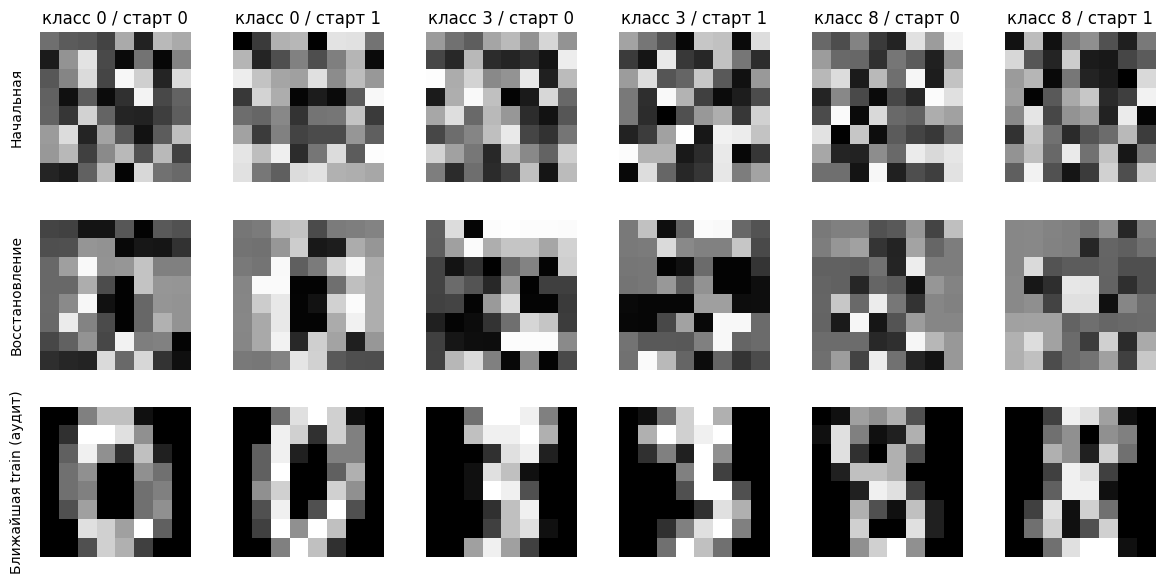

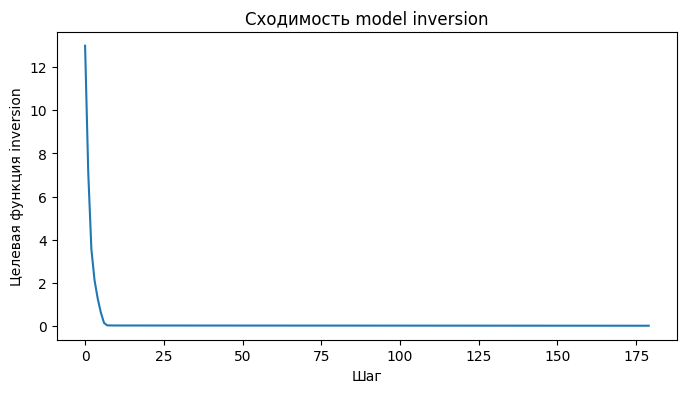

In [ ]:
inverse_probe_x = torch.full((2,64), .5, requires_grad=True)
inverse_probe = inversion_loss(clean, inverse_probe_x, torch.tensor([0,1]))
if inverse_probe is None:
    pending("D1")
else:
    assert inverse_probe.ndim == 0
    grad = torch.autograd.grad(inverse_probe, inverse_probe_x)[0]
    assert torch.isfinite(grad).all() and grad.abs().sum() > 0
    before_weights = [p.detach().clone() for p in clean.parameters()]
    for p in clean.parameters():
        p.requires_grad_(False)
    # Два старта для каждого из трёх классов.
    classes = torch.tensor([0,0,3,3,8,8], dtype=torch.long)
    torch.manual_seed(70)
    inv_x = torch.rand((6,64), requires_grad=True)
    initial = inv_x.detach().numpy().copy()
    opt_x = torch.optim.Adam([inv_x], lr=.04)
    inv_hist = []
    for _ in range(180):
        opt_x.zero_grad()
        loss = inversion_loss(clean, inv_x, classes)
        loss.backward(); opt_x.step()
        with torch.no_grad():
            inv_x.clamp_(0,1)
        inv_hist.append(loss.item())
    recon = inv_x.detach().numpy()
    assert all(torch.equal(p, old) for p,old in zip(clean.parameters(), before_weights))
    for p in clean.parameters():
        p.requires_grad_(True)
    # Аудиторский доступ: ближайшие train и held-out не входят в атакующую оптимизацию.
    rows, nearest_train = [], []
    for i, cls in enumerate(classes.numpy()):
        tri = np.flatnonzero(ytr == cls); tei = np.flatnonzero(yte == cls)
        # Одинаковое число кандидатов, чтобы размер множества не смещал nearest-neighbor baseline.
        nref = min(len(tri), len(tei)); tri, tei = tri[:nref], tei[:nref]
        dtr = ((Xtr[tri]-recon[i])**2).mean(1)
        dte = ((Xte[tei]-recon[i])**2).mean(1)
        nearest_train.append(Xtr[tri[dtr.argmin()]])
        rows.append({"class": int(cls), "restart": i%2,
                     "confidence": float(probs(clean,recon[i:i+1])[0,cls]),
                     "nearest_train_MSE": float(dtr.min()),
                     "nearest_test_MSE": float(dte.min()), "nref_each": nref})
    results["inversion"] = rows
    display(pd.DataFrame(rows))
    fig, ax = plt.subplots(3,6, figsize=(12,6))
    for i in range(6):
        for r, arr in enumerate([initial, recon, np.array(nearest_train)]):
            ax[r,i].imshow(arr[i].reshape(8,8), cmap="gray", vmin=0, vmax=1)
            ax[r,i].axis("off")
        ax[0,i].set_title(f"класс {classes[i].item()} / старт {i%2}")
    for r,label in enumerate(["Начальная", "Восстановление", "Ближайшая train (аудит)"]):
        ax[r,0].text(-.2,.5,label, transform=ax[r,0].transAxes, rotation=90, va="center")
    plt.tight_layout(); plt.show()
    plt.plot(inv_hist); plt.xlabel("Шаг"); plt.ylabel("Целевая функция inversion"); plt.title("Сходимость model inversion"); plt.show()

**Вывод.** Восстановления дают confidence ≈ 1.0 и напоминают цифры, но среднее MSE до ближайшей train-записи (0.147) практически равно MSE до ближайшей test-записи (0.146). Это прототип класса, а не извлечённая обучающая запись; целевая функция сходится за 180 шагов.

## E. Model extraction: локальный API с бюджетом

Цель: скопировать предсказания, а не восстановить точные веса.
Атакующий видит только свои query-входы и ответ API; метки `ytr`, `yte`, `y[pool_ids]` не используются в fit клона.
Ниже сравниваются soft probabilities и hard labels при равных бюджетах уникальных примеров.
Идея prediction-API extraction: [Tramèr et al.](https://arxiv.org/abs/1609.02943).
API является программной границей эксперимента, не защищённым процессом: владелец блокнота технически видит все переменные.

Чтобы не платить за одни и те же запросы повторно, один раз получаем 500 ответов и кэшируем их.
Модели с бюджетом 50/150/500 получают только соответствующий префикс ответов.
В эксплуатации метрики аудита потребовали бы отдельного доступа оценщика;
здесь он считает fidelity на test напрямую и не расходует бюджет атакующего.

### Задание E1. Дистилляция

Реализуйте soft cross-entropy по logits student и распределению teacher.
Не передавайте вероятности как logits в `cross_entropy`.
Для hard-label варианта используется стандартная cross-entropy с argmax teacher.

In [ ]:
def distill_loss(logits, teacher_p):
    """Soft cross-entropy между распределением teacher и student.

    -sum_c teacher_p[c] * log_softmax(student)[c], среднее по батчу.
    При равномерном teacher (0.1) и нулевых logits даёт log(10).
    """
    logp = F.log_softmax(logits, dim=1)
    return -(teacher_p * logp).sum(1).mean()

,queries_available,output,fidelity,clone_accuracy,victim_accuracy
0,50,soft,0.778,0.762,0.96
1,50,hard,0.736,0.730,0.96
2,150,soft,0.926,0.914,0.96
3,150,hard,0.892,0.880,0.96
4,500,soft,0.962,0.950,0.96
5,500,hard,0.948,0.938,0.96


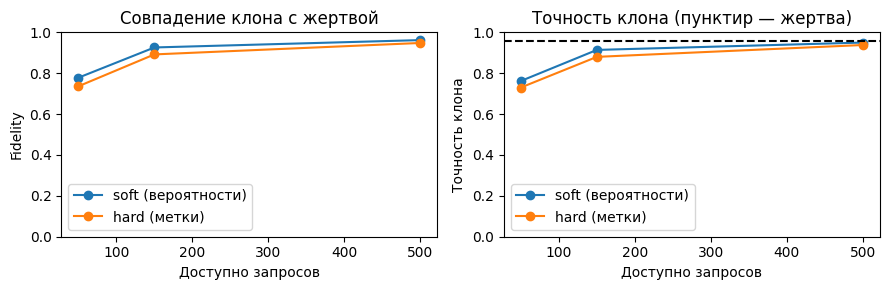

Всего запросов к API в этом опыте: 500


In [ ]:
class LocalAPI:
    def __init__(self, model, budget=500):
        self.__model = model
        self.budget, self.used = budget, 0
    def query(self, x):
        if self.used + len(x) > self.budget:
            raise RuntimeError("Query budget exceeded")
        self.used += len(x)
        return probs(self.__model, x)

dl_probe = distill_loss(torch.zeros(2,10, requires_grad=True), torch.full((2,10), .1))
if dl_probe is None:
    pending("E1")
else:
    assert torch.isclose(dl_probe.detach(), torch.tensor(np.log(10), dtype=torch.float32))
    api = LocalAPI(clean, budget=500)
    order = np.random.default_rng(80).permutation(len(Xpool))
    queries = Xpool[order]
    cached_answers = api.query(queries)
    assert api.used == 500
    try:
        api.query(queries[:1])
        raise AssertionError("Budget is not enforced")
    except RuntimeError:
        pass
    victim_test_labels = probs(clean, Xte).argmax(1)
    extraction_rows = []
    for budget in [50,150,500]:
        for mode in ["soft", "hard"]:
            # Это все обучающие данные, доступные данной модели-клону.
            qx, qp = tensor(queries[:budget]), tensor(cached_answers[:budget])
            student = new_model(64,10,seed=81,width=32)
            optimizer = torch.optim.Adam(student.parameters(), lr=.01, weight_decay=1e-4)
            for _ in range(160):
                optimizer.zero_grad()
                logits = student(qx)
                loss = distill_loss(logits, qp) if mode == "soft" else F.cross_entropy(logits, qp.argmax(1))
                loss.backward(); optimizer.step()
            clone_pred = probs(student.eval(), Xte).argmax(1)
            extraction_rows.append({"queries_available": budget, "output": mode,
                                    "fidelity": accuracy_score(victim_test_labels, clone_pred),
                                    "clone_accuracy": accuracy_score(yte, clone_pred),
                                    "victim_accuracy": baseline_acc})
    results["extraction"] = extraction_rows
    display(pd.DataFrame(extraction_rows))
    fig, ax = plt.subplots(1,2, figsize=(9,3))
    ef = pd.DataFrame(extraction_rows)
    for mode in ["soft","hard"]:
        sub = ef[ef.output == mode]
        ax[0].plot(sub.queries_available, sub.fidelity, "o-", label={"soft": "soft (вероятности)", "hard": "hard (метки)"}[mode])
        ax[1].plot(sub.queries_available, sub.clone_accuracy, "o-", label={"soft": "soft (вероятности)", "hard": "hard (метки)"}[mode])
    for a in ax:
        a.set(xlabel="Доступно запросов", ylim=(0,1)); a.legend()
    ax[0].set_ylabel("Fidelity"); ax[1].set_ylabel("Точность клона")
    ax[0].set_title("Совпадение клона с жертвой"); ax[1].set_title("Точность клона (пунктир — жертва)")
    ax[1].axhline(baseline_acc, color="black", linestyle="--")
    plt.tight_layout(); plt.show()
    print("Всего запросов к API в этом опыте:", api.used)

**Вывод.** Fidelity быстро растёт с бюджетом: 0.778 (soft) при 50 запросах и 0.962 при 500; soft-ответы стабильно лучше hard, так как вероятности несут больше информации. Точность клона ниже fidelity и ниже точности жертвы (пунктир): клон копирует и её ошибки.

## F. Протокол и отчёт

### Задание F1. Анализ и расширение

В основной части сформулируйте по одному выводу для A–E и один отрицательный/неоднозначный результат.
Для каждого укажите модель угроз, доступ атакующего, контроль, числитель и знаменатель метрики,
а также то, что из результата НЕ следует.

Выберите один вариант:

- **Backdoor**: сравните доли 0.05, 0.15, 0.25 на трёх seed; оставьте фиксированными патч и target.
- **Membership**: повторите оба режима на трёх seed; сравните AUC и PPV при pi=0.01/0.1/0.5.
- **Inversion**: сравните TV=0 и TV=0.05 на трёх seed; сопоставьте confidence и видимость класса.
- **Extraction**: повторите кривые бюджетов на трёх seed; сравните разброс soft/hard fidelity.

Выбор варианта согласуется до просмотра итогового test. При изменении гиперпараметров используйте
validation или отдельный development-стенд. Не используйте обучающую метку public pool для клона.
Покажите mean ± sample SD; не называйте интервал mean ± SD доверительным.
Не исключайте «неудачные» seed.

### Вопросы

- **Целостность данных**: чем случайная ошибка разметки отличается от намеренного poisoning?
- **Backdoor**: почему высокая clean accuracy не исключает высокий ASR? Зачем исключать target из знаменателя?
- **MIA**: зачем нужен shadow? Почему порог на target test означает утечку методики оценки?
- **Приватность**: почему AUC=0.5 у одной атаки не доказывает отсутствие утечек?
- **Inversion**: почему высокая confidence и похожая картинка не доказывают кражу конкретной записи?
- **Extraction**: почему модель-клон может иметь высокую fidelity, но низкую accuracy?
- **Защита**: почему weight decay и ограничение API не дают гарантии differential privacy?

### Что сдавать

Сдайте заполненный `.ipynb` с выводами и графиками, таблицу результатов, версии среды,
seed и краткое заключение (до 2 страниц). Все TODO должны быть реализованы.
Если блок пропущен, строка «не выполнено» не является результатом эксперимента.
Отсутствие ошибок при Run All само по себе не означает выполнения лабораторной.

## F. Выводы и воспроизводимость (задание F1)

Вариант расширения: **Extraction** — кривые бюджетов 50/150/500 повторены на трёх seed (81, 82, 83); результаты — в ячейке после части E. При 500 запросах fidelity 0.965 ± 0.003 (soft) против 0.946 ± 0.005 (hard), при 50 — 0.807 ± 0.071 против 0.779 ± 0.100: soft стабильно лучше, а малый бюджет даёт большой разброс между seed. Значения — mean ± sample SD, не доверительный интервал.

### По одному выводу для A–E

**A. Label flipping.** Случайная порча 10 % меток снизила clean test accuracy с 0.960 до 0.852, 30 % — до 0.652.
*Модель угроз:* атакующий меняет метки в обучающем наборе, не трогая входы. *Контроль:* доля 0 воспроизводит baseline. *Метрика:* числитель — верно классифицированные тестовые объекты, знаменатель — все 500 тестовых. *Не следует:* это нижняя граница вреда (простейшая, неоптимизированная атака); целевой poisoning при той же доле опаснее.

**B. Backdoor.** Отравив 15 % обучающих записей патчем 2×2, получили ASR = 1.000 при clean accuracy 0.956 (у чистой модели — 0.960). Чистая модель на том же триггере даёт ASR = 0.0, значит эффект создаёт обучение, а не само повреждение входа.
*Модель угроз:* dirty-label backdoor, цель — класс 0. *Контроль:* четыре клетки clean/poisoned × clean/triggered; oracle-стирание известного патча сбивает ASR до 0.002, подтверждая причинность. *Метрика ASR:* числитель — нетаргетные объекты, уведённые в target; знаменатель — **только** нетаргетные (450). *Не следует:* высокая clean accuracy ничего не говорит о безопасности, а стирание известного патча — не детектор неизвестных backdoor.

**C. Membership inference.** У переобученной модели (gap train−nonmember = 0.218) ROC-AUC атаки 0.672 и advantage TPR−FPR = 0.415; у регуляризованной (gap 0.165) — AUC 0.618, advantage 0.243.
*Модель угроз:* атакующий знает истинную метку и вектор вероятностей, порог калибрует на shadow-модели. *Контроль:* порог выбран только на shadow, membership-метки target открыты лишь оценщику. *Метрика:* balanced accuracy, TPR, FPR при фиксированном пороге. *Не следует:* высокая AUC на сбалансированном стенде не равна практическому риску — при доле участников π = 0.01, TPR = 0.6, FPR = 0.1 точность положительного вывода (PPV) всего 5.7 %.

**D. Model inversion.** Восстановленные изображения классов 0, 3, 8 дают confidence ≈ 1.0, но их расстояние до ближайшей обучающей записи (MSE ≈ 0.11–0.16) и до ближайшей held-out записи почти одинаково.
*Модель угроз:* white-box, атакующий знает веса и градиент по входу, но не использует train. *Контроль:* аудитор сравнивает с train и test при равном числе кандидатов. *Метрика:* confidence и nearest-neighbor MSE к train против test. *Не следует:* похожая картинка и уверенность 1.0 **не** доказывают кражу конкретной записи — восстановлен прототип класса, одинаково близкий к train и к невиданным данным.

**E. Model extraction.** При бюджете 500 запросов клон достигает fidelity 0.962 (soft) и 0.948 (hard); soft-метки стабильно лучше hard при любом бюджете (50: 0.778 против 0.736).
*Модель угроз:* атакующий видит только свои входы и ответы API, истинные метки не используются. *Контроль:* бюджет запросов форсируется, ответы кэшируются. *Метрика fidelity:* доля совпадений предсказаний клона и жертвы на тесте; accuracy — совпадение с истинной меткой. *Не следует:* fidelity ≠ accuracy — клон копирует и ошибки жертвы (clone_accuracy 0.950 < fidelity 0.962), поэтому высокая верность предсказаниям не означает высокое качество.

### Отрицательный/неоднозначный результат

**Model inversion не подтвердил извлечение обучающей записи.** Несмотря на confidence ≈ 1.0, среднее MSE до ближайшей train-записи (0.147) практически равно MSE до ближайшей test-записи (0.146) — восстановление одинаково «похоже» на участников и неучастников. Это корректный отрицательный результат: реализация верна (градиент доходит до входа, веса не менялись), но утверждение «украдена конкретная запись» не доказано. Так и должно быть для class-prototype inversion на этой модели.

### Ответы на вопросы

**Целостность данных: случайная ошибка разметки против poisoning.** Случайная ошибка не зависит от модели и в среднем лишь добавляет шум, снижая точность постепенно и симметрично по классам. Намеренный poisoning выбирается атакующим, чтобы максимизировать вред: целенаправленно сдвинуть границу, внедрить backdoor или повредить конкретный класс. При равной доле целевая атака опаснее случайной порчи того же объёма.

**Backdoor: почему высокая clean accuracy не исключает высокий ASR? Зачем исключать target?** Backdoor активируется только триггером, которого нет в чистом тесте, поэтому на чистых данных модель ведёт себя нормально (0.956) и прячет уязвимость; на триггере ASR = 1.0. Target-класс исключают из знаменателя, потому что объекты, уже принадлежащие классу 0, и без атаки предсказываются как 0 — засчитывать их в успех атаки нельзя, это завысило бы ASR.

**MIA: зачем shadow? Почему порог на target test — утечка методики?** Атакующий не знает истинных membership-меток target, поэтому не может подобрать порог напрямую. Shadow-модель он обучает сам на своих данных тем же алгоритмом, знает, кто в ней участник, и калибрует порог на ней. Если бы порог подбирался на target test, атака использовала бы информацию, которой у неё быть не должно (ответы оценщика), — это утечка методики и завышенная, нечестная оценка.

**Приватность: почему AUC = 0.5 одной атаки не доказывает отсутствие утечек?** AUC = 0.5 означает лишь, что **эта конкретная** атака (loss-threshold) не ранжирует участников. Более сильная атака (LiRA, атака по градиентам или по отдельным признакам) может выявить утечку. Отсутствие успеха у слабого противника — не гарантия приватности; гарантию даёт только формальный механизм вроде differential privacy.

**Inversion: почему похожая картинка и высокая confidence не доказывают кражу записи?** Оптимизация ищет вход, максимально уверенно относимый к классу, — она сходится к «типичному» представителю класса (прототипу), а не к конкретному обучающему примеру. Высокая confidence говорит лишь, что найден уверенный вход. Доказательством кражи было бы существенно меньшее расстояние до train, чем до held-out; у нас эти расстояния равны.

**Extraction: почему клон может иметь высокую fidelity, но низкую accuracy?** Fidelity измеряет совпадение с **жертвой**, а не с истиной. Клон учится воспроизводить выход жертвы, включая её ошибки. Если жертва где-то ошибается, точный клон повторит ошибку: он будет верен жертве (высокая fidelity), но неверен относительно правильного ответа (низкая accuracy). В пределе fidelity может быть 1.0 при accuracy, равной accuracy жертвы.

**Защита: почему weight decay и лимит API не дают гарантии differential privacy?** Weight decay эмпирически уменьшает переобучение и снижает успех MIA (advantage упал с 0.415 до 0.243), но это наблюдение на одном стенде, а не математическая граница: он не ограничивает влияние одной записи на модель формально. Лимит API замедляет extraction и MIA, но не исключает их: 500 запросов уже дали fidelity 0.962. DP же даёт доказуемую границу (ε, δ) на влияние любой отдельной записи при любом противнике — ни регуляризация, ни rate-limit такой гарантии не дают.

In [ ]:
required = ["baseline","label_flipping","backdoor","backdoor_defense","membership","inversion","extraction"]
missing = [name for name in required if name not in results]
print("Разделы с результатами:", list(results))
print("Незавершённые разделы:", missing)
print(f"Время исполнения: {time.perf_counter()-START:.1f} с")
# По желанию сохраните результаты в рабочую папку Jupyter:
# from pathlib import Path
# Path("lecture09_results.json").write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")

Разделы с результатами: ['baseline', 'label_flipping', 'backdoor', 'backdoor_defense', 'membership', 'inversion', 'extraction', 'extraction_seeds']
Незавершённые разделы: []
Время исполнения: 24.2 с
